# 11 — Blend v2 (Full 9-Model Ensemble)

Combines all nine model OOFs (Linear Regression, Random Forest, Gradient Boosting, XGBoost v1, MLP, XGBoost v2, XGBoost v3, LightGBM, CatBoost) and re-runs SLSQP weight optimisation.

Outputs:
- `outputs/test_local_pred_blend_v2.npy`
- `outputs/blend_v2_weights.json`

In [1]:
import os
os.environ['PYTHONWARNINGS'] = 'ignore'  # also silences warnings from n_jobs=-1 joblib subprocesses

import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.optimize import minimize
warnings.filterwarnings('ignore')

OUT_DIR = Path('../outputs')
DATA_DIR = Path('../data')

In [2]:
# Load development set target (train_local) and local test target
train_local = pd.read_parquet(OUT_DIR / 'train_local.parquet')
test_local  = pd.read_parquet(OUT_DIR / 'test_local.parquet')
y = train_local['blocked_days_Q1_2026'].astype(float).values
y_test = test_local['blocked_days_Q1_2026'].astype(float).values
print(f"Dev set y shape: {y.shape} | Local Test y shape: {y_test.shape}")

oof_files = {
    'LinearRegression': 'oof_LinearRegression.npy',
    'RandomForest':     'oof_RandomForest.npy',
    'GradientBoosting': 'oof_GradientBoosting.npy',
    'XGBoost':          'oof_XGBoost.npy',
    'XGBoost v2':       'oof_XGBoostV2.npy',
    'XGBoost v3':       'oof_XGBoostV3.npy',
    'MLP':              'oof_MLP.npy',
    'LightGBM':         'oof_LightGBM.npy',
    'CatBoost':         'oof_CatBoost.npy',
}
local_test_files = {
    'LinearRegression': 'test_local_pred_LinearRegression.npy',
    'RandomForest':     'test_local_pred_RandomForest.npy',
    'GradientBoosting': 'test_local_pred_GradientBoosting.npy',
    'XGBoost':          'test_local_pred_XGBoost.npy',
    'XGBoost v2':       'test_local_pred_XGBoostV2.npy',
    'XGBoost v3':       'test_local_pred_XGBoostV3.npy',
    'MLP':              'test_local_pred_mlp.npy',
    'LightGBM':         'test_local_pred_LightGBM.npy',
    'CatBoost':         'test_local_pred_CatBoost.npy',
}
oofs, local_test_preds = {}, {}
dev_scores, test_scores = {}, {}
for name, oof_name in oof_files.items():
    p_oof = OUT_DIR / oof_name
    p_lt  = OUT_DIR / local_test_files[name]
    if p_oof.exists():
        oof_loaded = np.load(p_oof)
        if oof_loaded.shape[0] != y.shape[0]:
            print(f'{name:<18s} | SHAPE MISMATCH: {y.shape[0]} vs {oof_loaded.shape[0]} (skip)')
            continue
        oofs[name] = np.clip(oof_loaded, 0, 90)
        mse = mean_squared_error(y, oofs[name])
        mae = mean_absolute_error(y, oofs[name])
        r2  = r2_score(y, oofs[name])
        dev_scores[name] = {'MSE': mse, 'MAE': mae, 'R2': r2}
        print(f'{name:<18s} | OOF  MSE = {mse:8.3f}  MAE = {mae:7.3f}  R2 = {r2:.3f}')
    else:
        print(f'{name:<18s} | OOF MISSING ({oof_name})')
    if p_lt.exists():
        local_test_preds[name] = np.load(p_lt)
        pred = np.clip(local_test_preds[name], 0, 90)
        mse_t = mean_squared_error(y_test, pred)
        mae_t = mean_absolute_error(y_test, pred)
        r2_t  = r2_score(y_test, pred)
        test_scores[name] = {'MSE': mse_t, 'MAE': mae_t, 'R2': r2_t}
        print(f'{"":<18s} | Test MSE = {mse_t:8.3f}  MAE = {mae_t:7.3f}  R2 = {r2_t:.3f}')
    else:
        print(f'{name:<18s} | LOCAL TEST PRED MISSING')

model_names = [m for m in oofs.keys() if m in local_test_preds]
print('\nModels in blend:', model_names)

Dev set y shape: (29008,) | Local Test y shape: (7253,)
LinearRegression   | OOF  MSE =  367.348  MAE =  12.502  R2 = 0.417
                   | Test MSE =  365.111  MAE =  12.287  R2 = 0.412
RandomForest       | OOF  MSE =  308.800  MAE =  10.548  R2 = 0.510
                   | Test MSE =  305.029  MAE =  10.320  R2 = 0.508
GradientBoosting   | OOF  MSE =  448.745  MAE =  11.214  R2 = 0.288
                   | Test MSE =  434.827  MAE =  10.888  R2 = 0.299
XGBoost            | OOF  MSE =  300.333  MAE =  10.217  R2 = 0.523
                   | Test MSE =  297.994  MAE =  10.036  R2 = 0.520
XGBoost v2         | OOF  MSE =  307.337  MAE =  10.426  R2 = 0.512
                   | Test MSE =  303.171  MAE =  10.239  R2 = 0.511
XGBoost v3         | OOF  MSE =  305.827  MAE =  10.397  R2 = 0.515
                   | Test MSE =  301.567  MAE =  10.211  R2 = 0.514
MLP                | OOF  MSE =  390.007  MAE =  10.498  R2 = 0.381
                   | Test MSE =  386.911  MAE =  10.430  R2 

In [3]:
oof_mat = np.column_stack([oofs[m] for m in model_names])
print('oof_mat:', oof_mat.shape)

# Equal-weight baseline
blend_eq = np.clip(oof_mat.mean(axis=1), 0, 90)
mse_eq = mean_squared_error(y, blend_eq)
mae_eq = mean_absolute_error(y, blend_eq)
r2_eq  = r2_score(y, blend_eq)
dev_scores['Equal-Blend'] = {'MSE': mse_eq, 'MAE': mae_eq, 'R2': r2_eq}
print(f'Equal-weight blend OOF MSE = {mse_eq:.3f}  MAE = {mae_eq:.3f}  R2 = {r2_eq:.3f}')

oof_mat: (29008, 9)
Equal-weight blend OOF MSE = 308.069  MAE = 10.419  R2 = 0.511


In [4]:
def blend_mse(w, M, y):
    return float(mean_squared_error(y, np.clip(M @ w, 0, 90)))

k = oof_mat.shape[1]
w0 = np.full(k, 1.0 / k)
res = minimize(blend_mse, w0, args=(oof_mat, y),
               method='SLSQP', bounds=[(0.0, 1.0)] * k,
               constraints=[{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}],
               options={'maxiter': 500, 'ftol': 1e-9})
w = res.x; w[w < 1e-4] = 0.0; w = w / w.sum()
print('Optimal weights:')
for m, wi in zip(model_names, w):
    print(f'  {m:<18s} = {wi:.4f}')

pred_opt = np.clip(oof_mat @ w, 0, 90)
mse_opt = mean_squared_error(y, pred_opt)
mae_opt = mean_absolute_error(y, pred_opt)
r2_opt  = r2_score(y, pred_opt)
dev_scores['Optimal-Blend'] = {'MSE': mse_opt, 'MAE': mae_opt, 'R2': r2_opt}
print(f'\nOptimal blend OOF MSE = {mse_opt:.3f}  MAE = {mae_opt:.3f}  R2 = {r2_opt:.3f}')

with open(OUT_DIR / 'blend_v2_weights.json', 'w') as f:
    json.dump({m: float(wi) for m, wi in zip(model_names, w)}, f, indent=2)

Optimal weights:
  LinearRegression   = 0.0000
  RandomForest       = 0.1424
  GradientBoosting   = 0.0000
  XGBoost            = 0.6038
  XGBoost v2         = 0.0000
  XGBoost v3         = 0.1196
  MLP                = 0.0493
  LightGBM           = 0.0848
  CatBoost           = 0.0000

Optimal blend OOF MSE = 298.392  MAE = 10.209  R2 = 0.526


In [5]:
# Build local test blend prediction
test_mat = np.column_stack([local_test_preds[m] for m in model_names])
final_lt = np.clip(test_mat @ w, 0, 90)
test_mse_blend_v2 = mean_squared_error(y_test, final_lt)
test_mae_blend_v2 = mean_absolute_error(y_test, final_lt)
test_r2_blend_v2  = r2_score(y_test, final_lt)
test_scores['Optimal-Blend'] = {'MSE': test_mse_blend_v2, 'MAE': test_mae_blend_v2, 'R2': test_r2_blend_v2}
print(f'Blend v2 Local Test MSE = {test_mse_blend_v2:.3f}  MAE = {test_mae_blend_v2:.3f}  R2 = {test_r2_blend_v2:.3f}')
np.save(OUT_DIR / 'test_local_pred_blend_v2.npy', final_lt)
print(f'Saved test_local_pred_blend_v2.npy | mean={final_lt.mean():.2f}')

Blend v2 Local Test MSE = 296.615  MAE = 10.034  R2 = 0.522
Saved test_local_pred_blend_v2.npy | mean=15.64


=== Dev (5-Fold OOF) metrics ===
                      MSE     MAE     R2
model                                   
Optimal-Blend     298.392  10.209  0.526
XGBoost           300.333  10.217  0.523
XGBoost v3        305.827  10.397  0.515
XGBoost v2        307.337  10.426  0.512
LightGBM          307.959  10.433  0.511
Equal-Blend       308.069  10.419  0.511
CatBoost          308.609  10.588  0.510
RandomForest      308.800  10.548  0.510
LinearRegression  367.348  12.502  0.417
MLP               390.007  10.498  0.381
GradientBoosting  448.745  11.214  0.288

=== Local Test metrics ===
                      MSE     MAE     R2
model                                   
Optimal-Blend     296.615  10.034  0.522
XGBoost           297.994  10.036  0.520
XGBoost v3        301.567  10.211  0.514
LightGBM          302.260  10.208  0.513
XGBoost v2        303.171  10.239  0.511
RandomForest      305.029  10.320  0.508
CatBoost          308.812  10.459  0.502
LinearRegression  365.111  12.287  0.

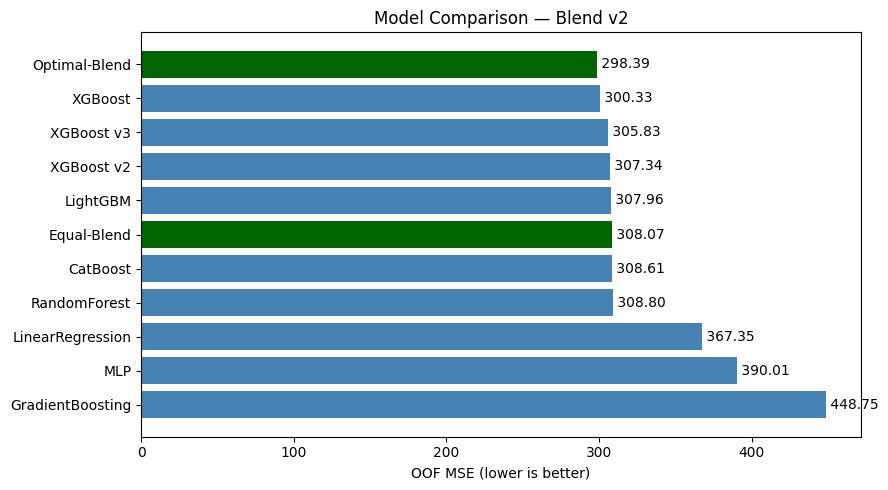

In [6]:
# Full metrics summary + comparison plot
summary_dev = pd.DataFrame(dev_scores).T[['MSE', 'MAE', 'R2']].round(3).sort_values('MSE')
summary_dev.index.name = 'model'
print('=== Dev (5-Fold OOF) metrics ===')
print(summary_dev.to_string())

summary_test = pd.DataFrame(test_scores).T[['MSE', 'MAE', 'R2']].round(3).sort_values('MSE')
summary_test.index.name = 'model'
print('\n=== Local Test metrics ===')
print(summary_test.to_string())

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['darkgreen' if 'Blend' in n else 'steelblue' for n in summary_dev.index]
ax.barh(summary_dev.index, summary_dev['MSE'].values, color=colors)
for i, v in enumerate(summary_dev['MSE'].values):
    ax.text(v, i, f' {v:.2f}', va='center')
ax.invert_yaxis()
ax.set_xlabel('OOF MSE (lower is better)')
ax.set_title('Model Comparison — Blend v2')
plt.tight_layout(); plt.savefig(OUT_DIR / 'blend_v2_comparison.png', dpi=120); plt.show()